In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [310]:
from sklearn.preprocessing import MinMaxScaler

small_df = pd.read_parquet('..\\data\\bm\\data_BM01P1_hits.parquet')
small_df = small_df.T

scaler = MinMaxScaler()
small_df = scaler.fit_transform(small_df)

small_df = small_df.T

In [311]:
def plt_bar(idx, x=20):
    plt.bar(range(x), small_df[idx])
    plt.show()

In [361]:
import torch.nn as nn 

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm1d(16),
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 8, kernel_size=4, stride=2, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [362]:
import torch 

torch_small_df = torch.from_numpy(small_df)
torch_small_df = torch_small_df.to(torch.float32)

In [363]:
conv = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4)
torch_small_df[1]

tensor([0.5766, 1.0000, 0.6685, 0.2758, 0.1003, 0.0111, 0.0084, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])

In [364]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [365]:
torch_small_df = HistDataset(torch_small_df)
dataloader = DataLoader(torch_small_df, batch_size=16, shuffle=False)

In [366]:
ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.001)

In [430]:
# first model training loop
losses = []
n_epochs = 1500
ae_conv.train()

for e in range(n_epochs):
    for pt in dataloader:
        recreated = ae_conv(pt)
        loss = criterion(recreated, pt)
        loss.backward()
        optimizer.step()
    losses.append(loss.detach().numpy())

    #print(f'Epoch: {e} | Loss: {loss.detach().numpy()}')  

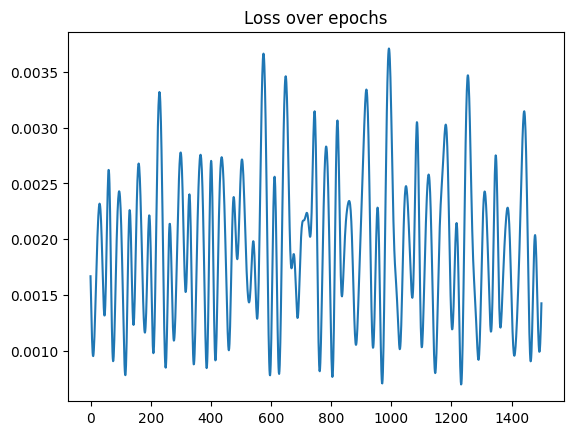

In [431]:
plt.title('Loss over epochs')
plt.plot(range(len(losses)), losses)

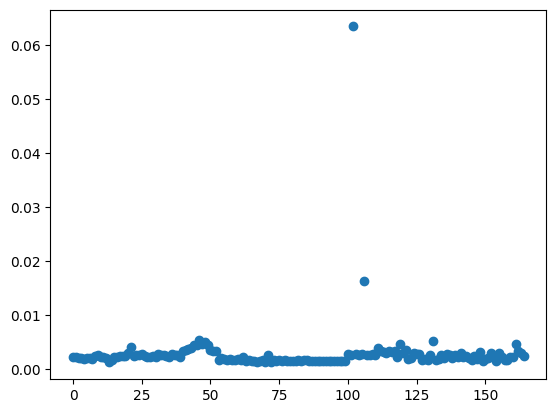

In [432]:
ae_conv.eval()
score = []
for batch in dataloader:
    for pt in batch:
        loss = criterion(ae_conv(pt.unsqueeze(0)), pt)
        score.append(loss.detach().numpy())

plt.scatter(range(len(score)), score)
plt.show()

In [433]:
top_scores = sorted(score)[-3:]
for s in top_scores:
    print(score.index(s))

46
106
102


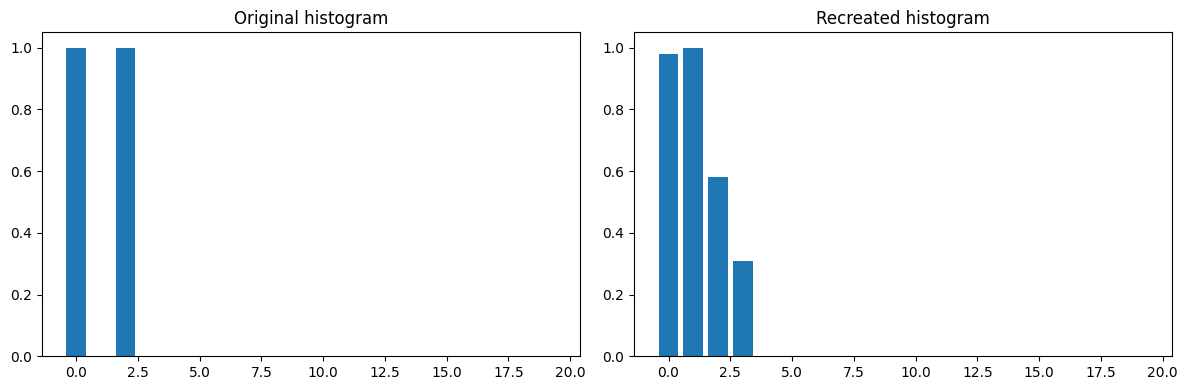

In [454]:
idx = 102
pred = ae_conv(torch_small_df[idx].unsqueeze(0))
pred = pred.detach().numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), small_df[idx])
axes[0].set_title("Original histogram")

axes[1].bar(range(len(pred)), pred)
axes[1].set_title("Recreated histogram")


plt.tight_layout()
plt.show()